<a href="https://colab.research.google.com/github/LosDatalovers/PRACTICA-PROFESIONALIZANTE-1/blob/main/practica_profesionalizante_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Grupo: Los Data Lovers  

## Integrantes:

1)- Almada, Sergio Daniel

2)- Beltramone, Mateo

3)- Guzmán, Nahir Dayana

4)- Navarro, Paola Giselle

5)- Oro, Yamil Elías

6)- Rivera Luna, Gonzalo Ezequiel

7)- Rojas, Marisa


In [1]:
!git clone https://github.com/LosDatalovers/PRACTICA-PROFESIONALIZANTE-1.git

fatal: destination path 'PRACTICA-PROFESIONALIZANTE-1' already exists and is not an empty directory.


In [2]:
cd /content/PRACTICA-PROFESIONALIZANTE-1/Datos Excel/

/content/PRACTICA-PROFESIONALIZANTE-1/Datos Excel


In [3]:
ls

'Carpetas_Set 20240328-agua.csv'  'Carpetas_Set 20240328.xlsx'   Resumen_Estadistico_Agua.xlsx
'Carpetas_Set 20240328.csv'        datos                         Resumen_Estadistico_Energia.xlsx


In [4]:
!pip install pandas
!pip install matplotlib
!pip install numpy
!pip install scipy
!pip install openpyxl
!pip install osmnx

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = 'Carpetas_Set 20240328.csv'

df = pd.read_csv(url)

print("Primeros diez registros del dataset:")
print(df.head(20))

print("\nDescripción del dataset:")
print(df.describe())

Primeros diez registros del dataset:
   Unnamed: 0 Unnamed: 1    Unnamed: 2  \
0       IdSet  IdCarpeta  IdPrestacion   
1          19         26        194817   
2          38         48        178504   
3          25         36        148535   
4           7         10        216520   
5          35         44        212953   
6          37         47         11429   
7          35         44         10554   
8           3          4        187671   
9          16         20        172994   
10         43         58        193366   
11         53         73         13069   
12         42         57        213636   
13         54         75         13380   
14         53         73         13427   
15         41         56        196218   
16         54         75        156173   
17         55         49        220981   
18          9         13        224786   
19         34         45         91275   

                          Fact 3624 Flia     3632 Com     Unnamed: 4  \
0       

<ipython-input-6-3d4928e04289>:29: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_equilibrado = pd.concat([df_equilibrado, empresas_grupo])


Grupo E tiene menos de 2 coordenadas únicas, se omite la optimización.


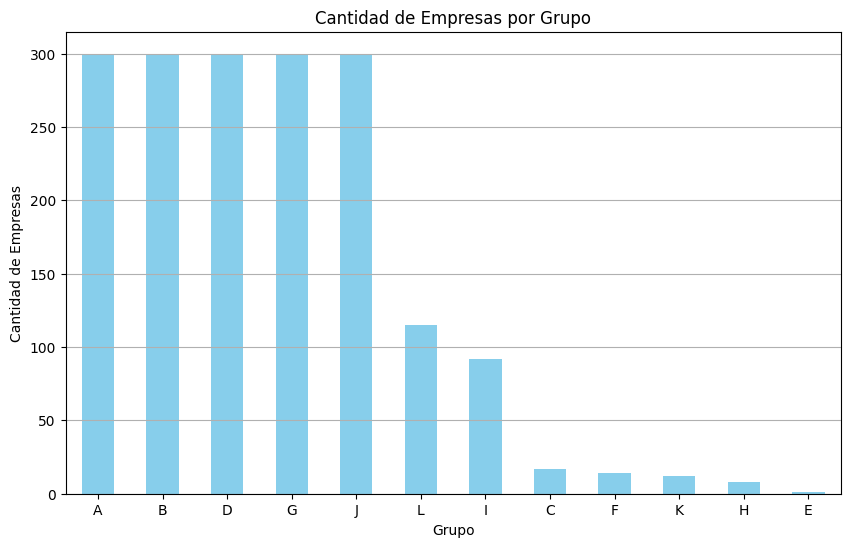

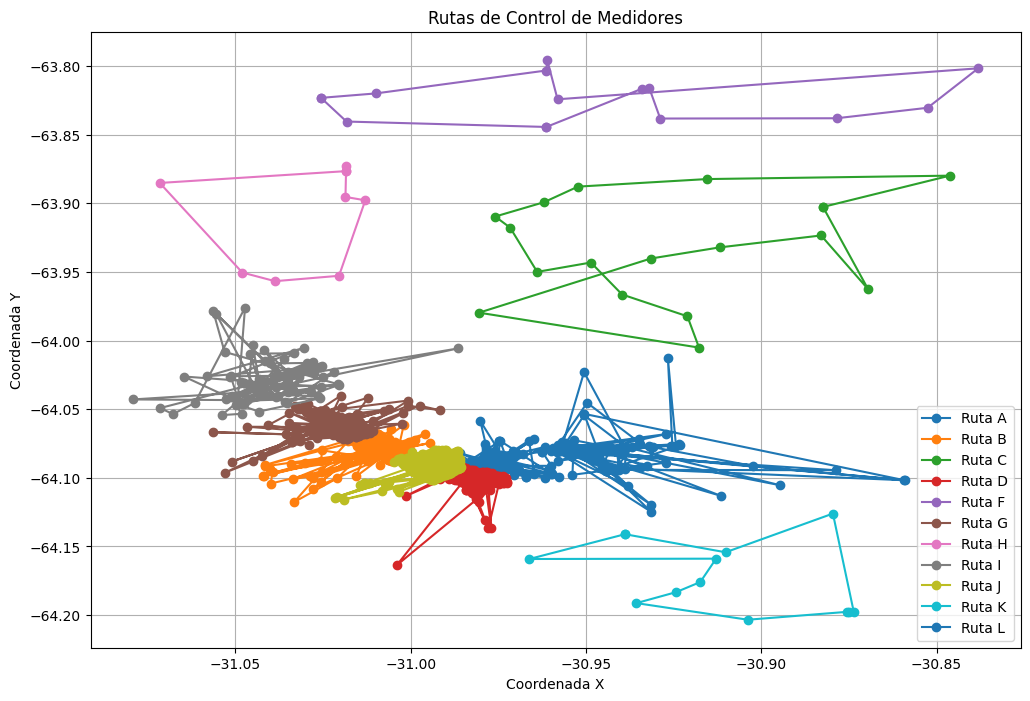

Grupo A: estimada de = 7h 57m horas
Grupo B: estimada de = 7h 54m horas
Grupo C: estimada de = 0h 34m horas
Grupo D: estimada de = 7h 55m horas
Grupo F: estimada de = 0h 28m horas
Grupo G: estimada de = 7h 53m horas
Grupo H: estimada de = 0h 15m horas
Grupo I: estimada de = 2h 31m horas
Grupo J: estimada de = 7h 58m horas
Grupo K: estimada de = 0h 23m horas
Grupo L: estimada de = 2h 53m horas


In [6]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import networkx as nx
import matplotlib.pyplot as plt

def leerLimpiar():
    url = 'Carpetas_Set 20240328.xlsx'
    df = pd.read_excel(url, sheet_name='Energia', skiprows=1, usecols="C:D,H:I")
    df_limpio = df[(df['CoordX'] != 0) & (df['CoordY'] != 0)].drop_duplicates(subset='Nombre').copy()
    return df_limpio

def predict(df, num_grupos):
    kmeans = KMeans(n_clusters=num_grupos, random_state=42)
    df['Grupo'] = kmeans.fit_predict(df[['CoordX', 'CoordY']])

    # Asignar letras a los grupos en lugar de números
    df['Grupo'] = df['Grupo'].apply(lambda x: chr(x + 65))  # Asignar letras A, B, C, etc.

    # Rebalanceo de los grupos
    max_empresas_por_grupo = len(df) // num_grupos
    df_equilibrado = pd.DataFrame(columns=df.columns)

    for grupo in range(num_grupos):
        empresas_grupo = df[df['Grupo'] == chr(grupo + 65)]
        if len(empresas_grupo) > max_empresas_por_grupo:
            empresas_grupo = empresas_grupo.sample(max_empresas_por_grupo, random_state=42)

        df_equilibrado = pd.concat([df_equilibrado, empresas_grupo])

    df_equilibrado['Orden'] = df_equilibrado.groupby('Grupo').cumcount() + 1
    df_equilibrado['NombreSectorizado'] = df_equilibrado['Grupo'].astype(str) + df_equilibrado['Orden'].astype(str)

    return df_equilibrado

def optimizador(df):
    rutas_optimas = {}
    estimado = {}
    velocidad = 5  # Velocidad en km/h
    tiempoEstimado = 4  # 4 horas para 150 paradas

    for grupo in df['Grupo'].unique():
        subgrupo = df[df['Grupo'] == grupo]
        coordenadas = subgrupo[['CoordX', 'CoordY']].drop_duplicates()

        if len(coordenadas) < 2:
            print(f"Grupo {grupo} tiene menos de 2 coordenadas únicas, se omite la optimización.")
            continue

        G = nx.complete_graph(len(coordenadas))
        distancias = {(i, j): np.linalg.norm(np.array(coordenadas.iloc[i]) - np.array(coordenadas.iloc[j])) for i in range(len(coordenadas)) for j in range(len(coordenadas))}
        nx.set_edge_attributes(G, distancias, 'weight')

        tsp_ruta = nx.approximation.traveling_salesman_problem(G, weight='weight')
        rutas_optimas[grupo] = tsp_ruta

        # Calcular la distancia total de la ruta
        distancia_total_km = sum(G.edges[tsp_ruta[i], tsp_ruta[i + 1]]['weight'] for i in range(len(tsp_ruta) - 1))

        # Calcular el tiempo de caminata basado en la distancia total
        tiempo_caminata_horas = distancia_total_km / velocidad

        numero_paradas = len(coordenadas)
        tiempo_estimado_horas = (numero_paradas / 150) * tiempoEstimado + tiempo_caminata_horas

        horas = int(tiempo_estimado_horas)
        minutos = int((tiempo_estimado_horas - horas) * 60)

        estimado[grupo] = f"{horas}h {minutos}m"

    return rutas_optimas, estimado

def visualizarRutas(df, rutas):
    plt.figure(figsize=(12, 8))

    for grupo, ruta in rutas.items():
        subgrupo = df[df['Grupo'] == grupo].reset_index(drop=True)
        coord_ruta = subgrupo.iloc[ruta][['CoordX', 'CoordY']]

        plt.plot(coord_ruta['CoordX'], coord_ruta['CoordY'], marker='o', label=f'Ruta {grupo}')

    plt.title('Rutas de Control de Medidores')
    plt.xlabel('Coordenada X')
    plt.ylabel('Coordenada Y')
    plt.legend()
    plt.grid()
    plt.show()

def empresas(df):
    conteo = df['Grupo'].value_counts()

    plt.figure(figsize=(10, 6))
    conteo.plot(kind='bar', color='skyblue')
    plt.title('Cantidad de Empresas por Grupo')
    plt.xlabel('Grupo')
    plt.ylabel('Cantidad de Empresas')
    plt.xticks(rotation=0)
    plt.grid(axis='y')
    plt.show()

df = leerLimpiar()
df = df.head(3600)
df = predict(df, num_grupos=12)
rutas, tiempo = optimizador(df)
empresas(df)
visualizarRutas(df, rutas)

for grupo, tiempo_grupo in tiempo.items():
    print(f"Grupo {grupo}: estimada de = {tiempo_grupo} horas")

<ipython-input-7-5124b48f7680>:31: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_equilibrado = pd.concat([df_equilibrado, empresas_grupo])


Grupo C tiene menos de 2 coordenadas únicas, se omite la optimización.
Grupo H tiene menos de 2 coordenadas únicas, se omite la optimización.


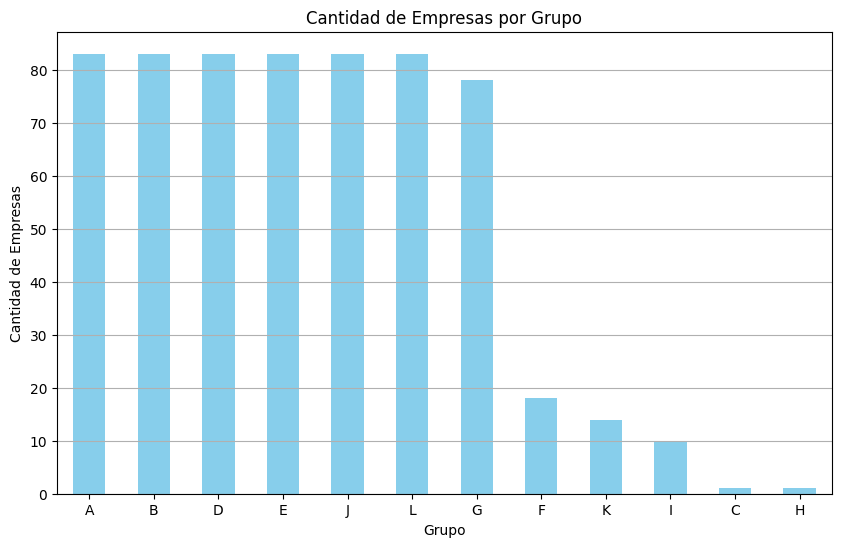

/usr/local/lib/python3.10/dist-packages/osmnx/graph.py:191: FutureWarning: The expected order of coordinates in `bbox` will change in the v2.0.0 release to `(left, bottom, right, top)`.
  G = graph_from_bbox(


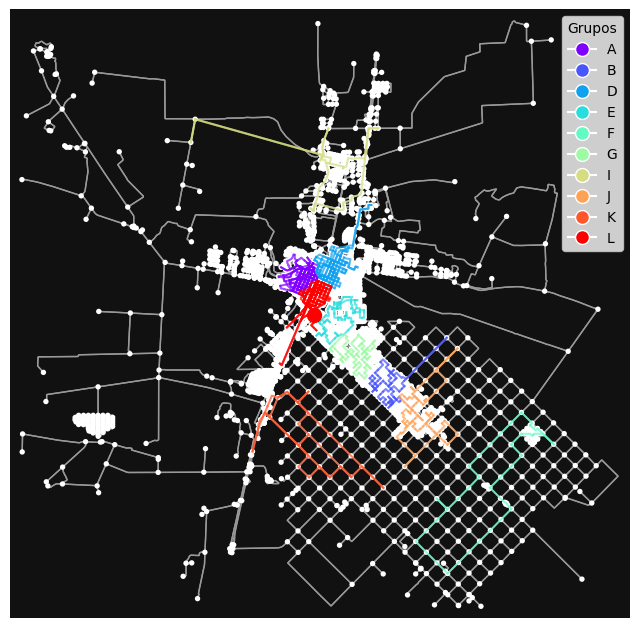

Grupo A: estimada de = 2h 4m horas
Grupo B: estimada de = 2h 14m horas
Grupo D: estimada de = 2h 12m horas
Grupo E: estimada de = 2h 13m horas
Grupo F: estimada de = 0h 30m horas
Grupo G: estimada de = 2h 6m horas
Grupo I: estimada de = 0h 18m horas
Grupo J: estimada de = 2h 14m horas
Grupo K: estimada de = 0h 22m horas
Grupo L: estimada de = 2h 12m horas


In [7]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import networkx as nx
import matplotlib.pyplot as plt
import osmnx as ox
import matplotlib.cm as cm

def leerLimpiar():
    url = 'Carpetas_Set 20240328.xlsx'
    df = pd.read_excel(url, sheet_name='Energia', skiprows=1, usecols="C:D,H:I")
    df_limpio = df[(df['CoordX'] != 0) & (df['CoordY'] != 0)].drop_duplicates(subset='Nombre').copy()
    return df_limpio

def predict(df, num_grupos):
    kmeans = KMeans(n_clusters=num_grupos, random_state=42)
    df['Grupo'] = kmeans.fit_predict(df[['CoordX', 'CoordY']])

    # Asignar letras a los grupos en lugar de números
    df['Grupo'] = df['Grupo'].apply(lambda x: chr(x + 65))  # Asignar letras A, B, C, etc.

    # Rebalanceo de los grupos
    max_empresas_por_grupo = len(df) // num_grupos
    df_equilibrado = pd.DataFrame(columns=df.columns)

    for grupo in range(num_grupos):
        empresas_grupo = df[df['Grupo'] == chr(grupo + 65)]
        if len(empresas_grupo) > max_empresas_por_grupo:
            empresas_grupo = empresas_grupo.sample(max_empresas_por_grupo, random_state=42)

        df_equilibrado = pd.concat([df_equilibrado, empresas_grupo])

    df_equilibrado['Orden'] = df_equilibrado.groupby('Grupo').cumcount() + 1
    df_equilibrado['NombreSectorizado'] = df_equilibrado['Grupo'].astype(str) + df_equilibrado['Orden'].astype(str)

    return df_equilibrado

def optimizador(df):
    rutas_optimas = {}
    estimado = {}  # Dicciónario para almacenar el tiempo estimado de cada grupo

    velocidad = 5  # Velocidad en km/h
    tiempo_estimado_por_150_paradas = 4  # 4 horas para 150 paradas

    for grupo in df['Grupo'].unique():
        subgrupo = df[df['Grupo'] == grupo]
        coordenadas = subgrupo[['CoordX', 'CoordY']].drop_duplicates()

        if len(coordenadas) < 2:
            print(f"Grupo {grupo} tiene menos de 2 coordenadas únicas, se omite la optimización.")
            continue

        G = nx.complete_graph(len(coordenadas))
        distancias = {(i, j): np.linalg.norm(np.array(coordenadas.iloc[i]) - np.array(coordenadas.iloc[j])) for i in range(len(coordenadas)) for j in range(len(coordenadas))}
        nx.set_edge_attributes(G, distancias, 'weight')

        tsp_ruta = nx.approximation.traveling_salesman_problem(G, weight='weight')
        rutas_optimas[grupo] = tsp_ruta

        # Calcular la distancia total de la ruta
        distancia_total_km = sum(G.edges[tsp_ruta[i], tsp_ruta[i + 1]]['weight'] for i in range(len(tsp_ruta) - 1))

        # Calcular el tiempo de caminata basado en la distancia total
        tiempo_caminata_horas = distancia_total_km / velocidad

        # Ajustar el tiempo total usando el valor estimado de 4 horas para 150 paradas
        numero_paradas = len(coordenadas)
        tiempo_estimado_horas = (numero_paradas / 150) * tiempo_estimado_por_150_paradas + tiempo_caminata_horas

        horas = int(tiempo_estimado_horas)
        minutos = int((tiempo_estimado_horas - horas) * 60)

        estimado[grupo] = f"{horas}h {minutos}m"

    return rutas_optimas, estimado

def visualizarRutas(df, rutas):
    centro = (-30.9918586, -64.0970209)  # Coordenadas de la cooperativa
    radio = 10000  # Aumentar el radio a 10,000 metros
    G = ox.graph_from_point(centro, dist=radio, network_type='all')

    # Crear la columna 'Nodo' en el DataFrame
    df['Nodo'] = df.apply(lambda row: ox.distance.nearest_nodes(G, row['CoordY'], row['CoordX']), axis=1)

    fig, ax = ox.plot_graph(G, show=False, close=False)
    ax.scatter(centro[1], centro[0], color='red', s=100, label='Cooperativa', zorder=5)

    colores = cm.rainbow(np.linspace(0, 1, len(rutas)))  # Generar colores únicos para cada grupo

    for color, (grupo, ruta) in zip(colores, rutas.items()):
        # Agrupar las paradas con las mismas coordenadas
        coord_paradas = df[df['Grupo'] == grupo][['CoordX', 'CoordY']].drop_duplicates()

        # Marcar los puntos de parada (nodos) en el mapa
        for idx, row in coord_paradas.iterrows():
            ax.scatter(row['CoordX'], row['CoordY'], color=color, s=100, zorder=6, label=f'Grupo {grupo}' if idx == 0 else "")  # Usar el color del grupo

        # Dibujar las rutas entre los nodos de parada
        for i in range(len(ruta) - 1):
            nodo_actual = df.loc[df['Grupo'] == grupo, 'Nodo'].values[ruta[i]]
            nodo_siguiente = df.loc[df['Grupo'] == grupo, 'Nodo'].values[ruta[i + 1]]

            # Verificar si ambos nodos están en el grafo y calcular la ruta más corta
            if nodo_actual in G and nodo_siguiente in G:
                ruta_mas_corta = nx.shortest_path(G, nodo_actual, nodo_siguiente, weight='length')
                x_coords = [G.nodes[n]['x'] for n in ruta_mas_corta]
                y_coords = [G.nodes[n]['y'] for n in ruta_mas_corta]

                # Dibujar la ruta más corta entre nodos en el grafo
                ax.plot(x_coords, y_coords, color=color, alpha=0.7)

    # Agregar leyenda solo de grupos y colores
    handles = [plt.Line2D([0], [0], marker='o', color='w', label=grupo, markersize=10, markerfacecolor=color) for grupo, color in zip(rutas.keys(), colores)]
    ax.legend(handles=handles, title="Grupos")
    plt.show()

def empresas(df):
    conteo = df['Grupo'].value_counts()

    plt.figure(figsize=(10, 6))
    conteo.plot(kind='bar', color='skyblue')
    plt.title('Cantidad de Empresas por Grupo')
    plt.xlabel('Grupo')
    plt.ylabel('Cantidad de Empresas')
    plt.xticks(rotation=0)
    plt.grid(axis='y')
    plt.show()

# Cargar, predecir y optimizar
df = leerLimpiar()
df = df.head(1000)  # Usar solo los primeros 1000 datos
df = predict(df, num_grupos=12)
rutas, tiempo = optimizador(df)

# Visualizar resultados
empresas(df)
visualizarRutas(df, rutas)

# Mostrar tiempo estimado por grupo
for grupo, tiempo_grupo in tiempo.items():
    print(f"Grupo {grupo}: estimada de = {tiempo_grupo} horas")